<a href="https://colab.research.google.com/github/muntadher995/crude-oil-price-model/blob/main/crude-oil-price-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


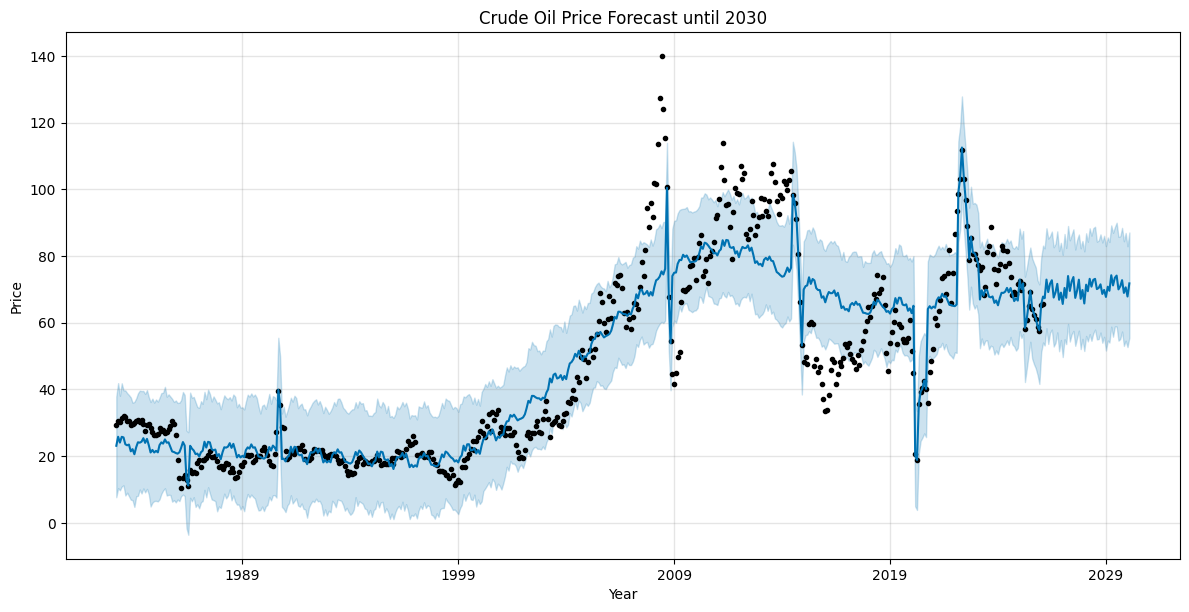

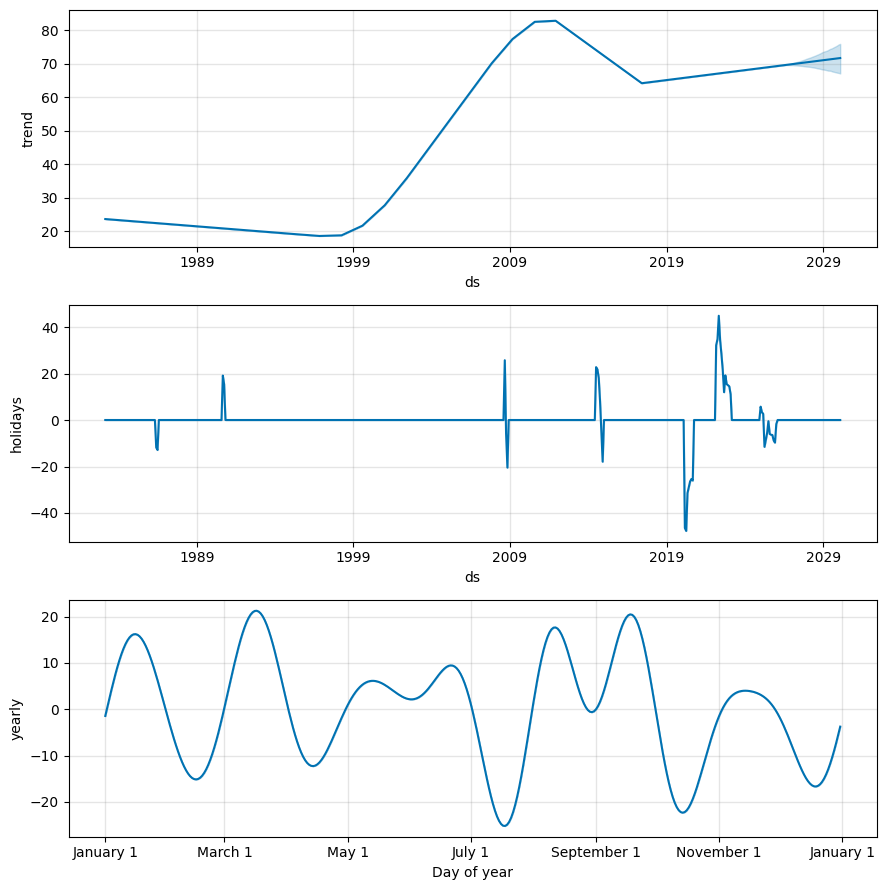

In [4]:
# 1️⃣ استدعاء المكتبات
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

%matplotlib inline

# 2️⃣ قراءة البيانات
df = pd.read_csv("crude-oil-price.csv")  # اسم الملف كما ذكرت
df['Date'] = pd.to_datetime(df['date'])
df = df.rename(columns={'Date': 'ds', 'price': 'y'})  # Prophet يحتاج ds و y

# Fix: Remove timezone information from the 'ds' column
df['ds'] = df['ds'].dt.tz_localize(None)

# 3️⃣ إضافة الأحداث الكبرى المؤثرة على أسعار النفط
holidays = pd.DataFrame({
    'holiday': [
        'oil_glut_1986', 'gulf_war_1990',
        'global_financial_crisis_2008', 'price_drop_2014',
        'covid_2020', 'oil_price_war_2020',
        'ukraine_crisis_2022', 'mid_east_tension_2025'
    ],
    'ds': pd.to_datetime([
        '1986-06-01',
        '1990-08-02',
        '2008-09-01',
        '2014-07-01',
        '2020-03-01',
        '2020-03-08',
        '2022-02-24',
        '2025-01-01'
    ]),
    'lower_window': [0,0,0,0,0,0,0,0],
    'upper_window': [30,90,90,180,180,180,365,365]
})


model = Prophet(holidays=holidays, yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(df[['ds','y']])

future = model.make_future_dataframe(periods=12*(2030 - df['ds'].dt.year.max()), freq='M')

#  التنبؤ بالأسعار
forecast = model.predict(future)

#  رسم النتائج
fig = model.plot(forecast, figsize=(12,6))
plt.title("Crude Oil Price Forecast until 2030")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

fig2 = model.plot_components(forecast)
plt.show()